In [47]:
# 1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones,
# primeras filas, tipos de datos y define qué representa una fila.

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")
df.head(10)



,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [48]:
df.info

<bound method DataFrame.info of       mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu

In [49]:
df.shape

(398, 9)

In [50]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

In [51]:
#<!-- 2. Clasifica `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`,
#`model_year`, `origin` y `name`. Identifica qué variables, aunque puedan verse numéricas,
#"conviene tratar como categorías o variables temporales. --> -->

df.dtypes

df["weight"]=df["weight"].astype(float)
df["cylinders"]=df["cylinders"].astype(float)
df.dtypes


mpg             float64
cylinders       float64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

In [52]:
#<!-- 3. Analiza valores faltantes y duplicados exactos. ¿En qué variable ##proporción representan? -->


valores_nulos= pd.DataFrame({
    "numero_nulos": df.isna().sum(),
    "porcentaje": df.isna().mean()*100
}).sort_values("porcentaje",ascending=False)

valores_nulos

,numero_nulos,porcentaje
horsepower,6,1.507538
mpg,0,0.000000
cylinders,0,0.000000
displacement,0,0.000000
weight,0,0.000000
acceleration,0,0.000000
model_year,0,0.000000
origin,0,0.000000
name,0,0.000000


In [53]:
numero_duplicados= df.duplicated().sum()
duplicados=df[df.duplicated(keep=False)].sort_values(list(df.columns))

print(numero_duplicados)

0


In [54]:
# 4. Estudia la cardinalidad de #`name`. ¿Cuántos nombres distintos #hay? ¿Que un nombre

nombres_unicos=df["name"].nunique()
nombres_unicos


305

In [55]:
#5. Calcula estadísticos descriptivos de `mpg`, `weight` y `horsepower`: media, mediana,
#desviación estándar, cuartiles e IQR. Interpreta qué te dicen sobre un automóvil “típico” y
#sobre la dispersión.

resumen=df[["mpg","weight","horsepower"]].agg(["mean","median","std"])
resumen
q=df[["mpg","weight","horsepower"]].quantile([0.25,0.75]).T

q.columns=['q1','q3']
q['iqr']=q['q3']-q['q1']
q


,q1,q3,iqr
mpg,17.50,29.0,11.50
weight,2223.75,3608.0,1384.25
horsepower,75.00,126.0,51.00


<Axes: xlabel='mpg', ylabel='Count'>

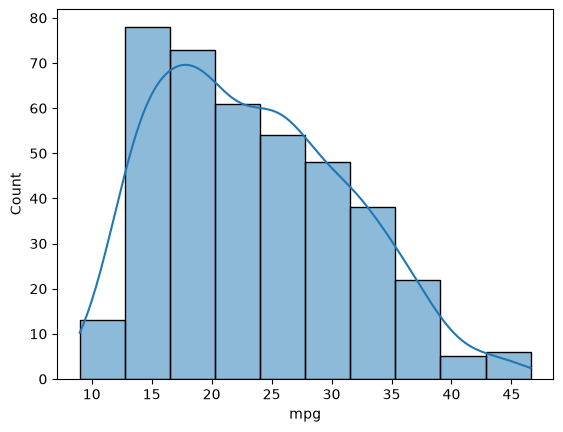

In [56]:
#6. Analiza la distribución de `mpg` con histograma y KDE.
sns.histplot(data=df,x="mpg", bins=10, 
kde=True)

,q1,q3,iqr
weight,2223.75,3608.0,1384.25


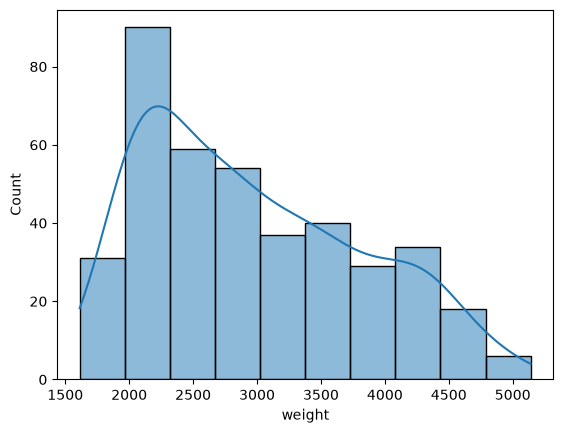

In [57]:

#7. Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? ¿Hay valores
#extremos según la regla del IQR? Documenta el cálculo.
sns.histplot(data=df,x="weight", bins=10, kde=True)

q=df[["weight"]].quantile([0.25,0.75]).T

q.columns=['q1','q3']
q['iqr']=q['q3']-q['q1']
q




<Axes: xlabel='weight'>

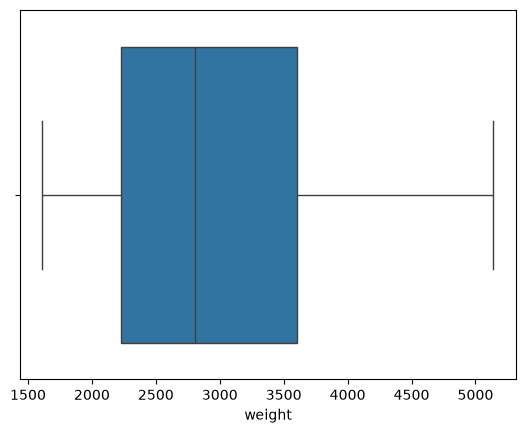

In [58]:
sns.boxplot(data=df,x="weight")

In [59]:
#8. Detecta outliers en `horsepower` usando 1.5·IQR. Lista los vehículos identificados y
#comenta si parecen errores evidentes o automóviles de alta potencia plausibles.

q= df[["horsepower"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]

lower= q["q1"]-1.5*q["iqr"]


upper=q["q3"]+1.5*q["iqr"]


df_sin= df[(df["horsepower"] < lower["horsepower"]) & (df["horsepower"] > upper["horsepower"])]
df_sin




,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name


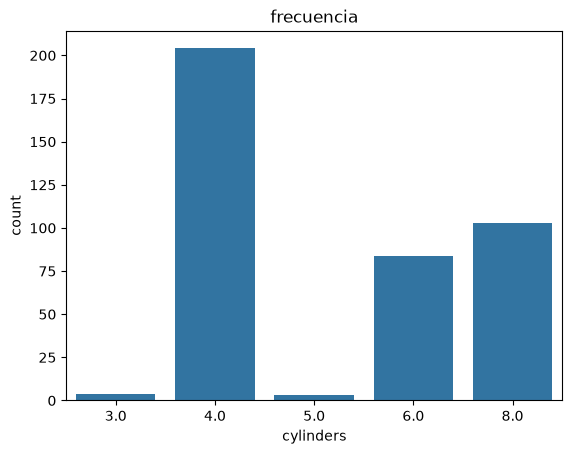

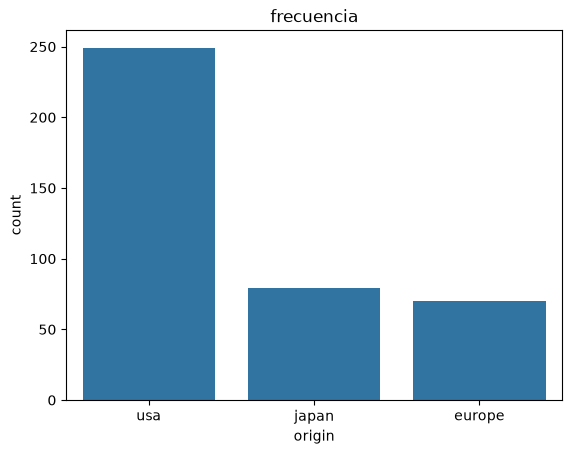

In [60]:
#9. Explora `cylinders` y `origin` mediante frecuencias y gráficos de barras. ¿Qué categorías
#dominan el dataset? ¿Hay categorías con muy pocos casos?

for col in ["cylinders","origin"]:
    sns.countplot(data=df,x=col)
    plt.title(f"frecuencia")
    plt.show()

<Axes: xlabel='cylinders', ylabel='mpg'>

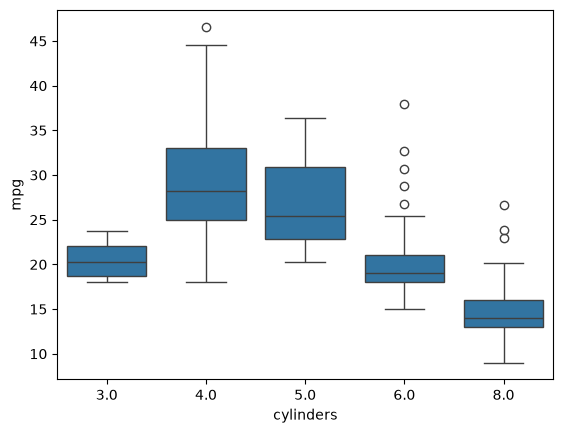

In [61]:
#10. Compara `mpg` entre vehículos con distinto número de cilindros mediante boxplot y
#medias/medianas por grupo. ¿Qué patrón general observas?
q=df[["mpg","cylinders"]].quantile([0.25,0.75]).T

q.columns=['q1','q3']
q['iqr']=q['q3']-q['q1']
q
sns.boxplot(data=df,x="cylinders",y="mpg")


          q1     q3   iqr
origin                   
europe  24.0  30.65  6.65
japan   25.7  34.05  8.35
usa     15.0  24.00  9.00


<Axes: xlabel='origin', ylabel='mpg'>

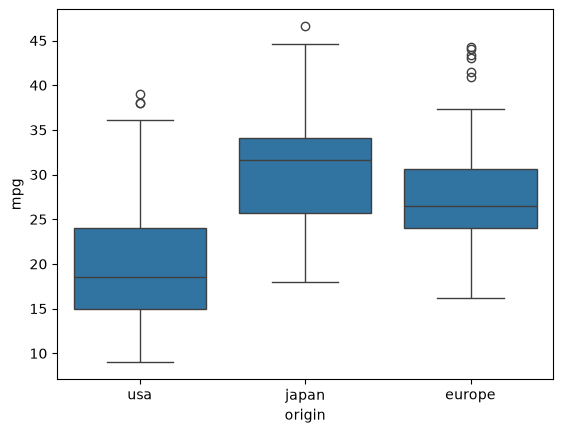

In [62]:
#11. Compara `mpg` entre los tres orígenes del dataset. Usa boxplot y estadísticas por grupo.
q = (
    df.groupby("origin")["mpg"]
    .quantile([0.25, 0.75])
    .unstack()
)
q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]
print(q)

sns.boxplot(data=df, x="origin", y="mpg")

<Axes: xlabel='mpg', ylabel='weight'>

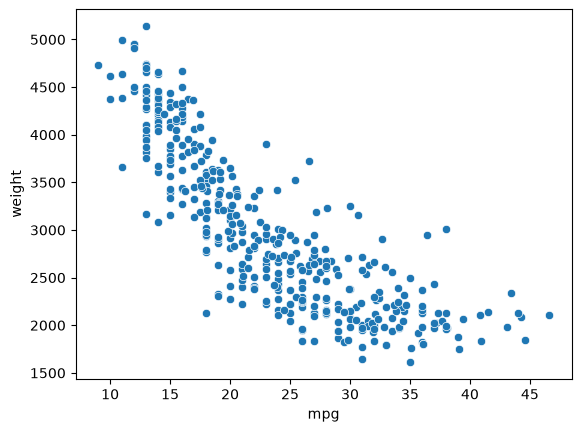

In [63]:
#12. Estudia la relación entre `weight` y `mpg` con un scatterplot y la correlación
sns.scatterplot(data=df,x="mpg", y="weight")


Correlación Horsepower - MPG: -0.7784
Correlación Weight - MPG:     -0.8317


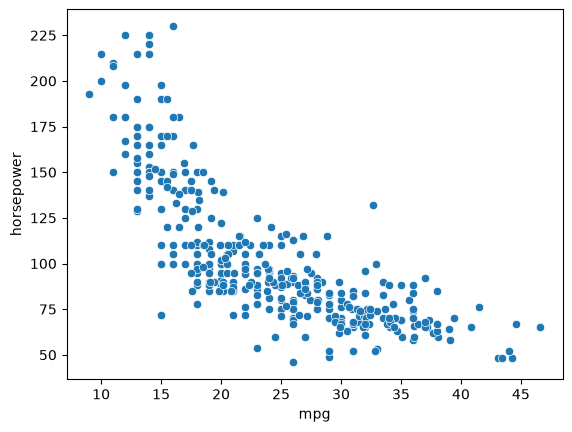

In [64]:
#13. Estudia la relación entre `horsepower` y `mpg` con scatterplot y correlación. Compara su
#intensidad con la relación `weight`–`mpg`.

sns.scatterplot(data=df,x="mpg",y="horsepower")
df_clean = df.dropna(subset=['horsepower']).copy()
corr_hp_mpg = df_clean['horsepower'].corr(df_clean['mpg'])
corr_weight_mpg = df['weight'].corr(df['mpg'])

print(f"Correlación Horsepower - MPG: {corr_hp_mpg:.4f}")
print(f"Correlación Weight - MPG:     {corr_weight_mpg:.4f}")


<Axes: >

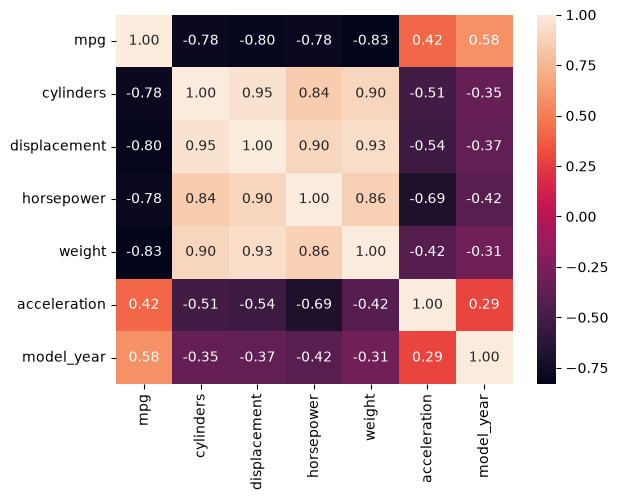

In [65]:
# 14. Construye una matriz de correlación y heatmap de las variables numéricas. Identifica las
# tres variables con mayor asociación lineal absoluta con `mpg` y comenta posibles
# redundancias entre predictores.
columnas_numericas=df.select_dtypes(include="number")
corr=columnas_numericas.corr()
sns.heatmap(corr,annot=True, fmt=".2f")

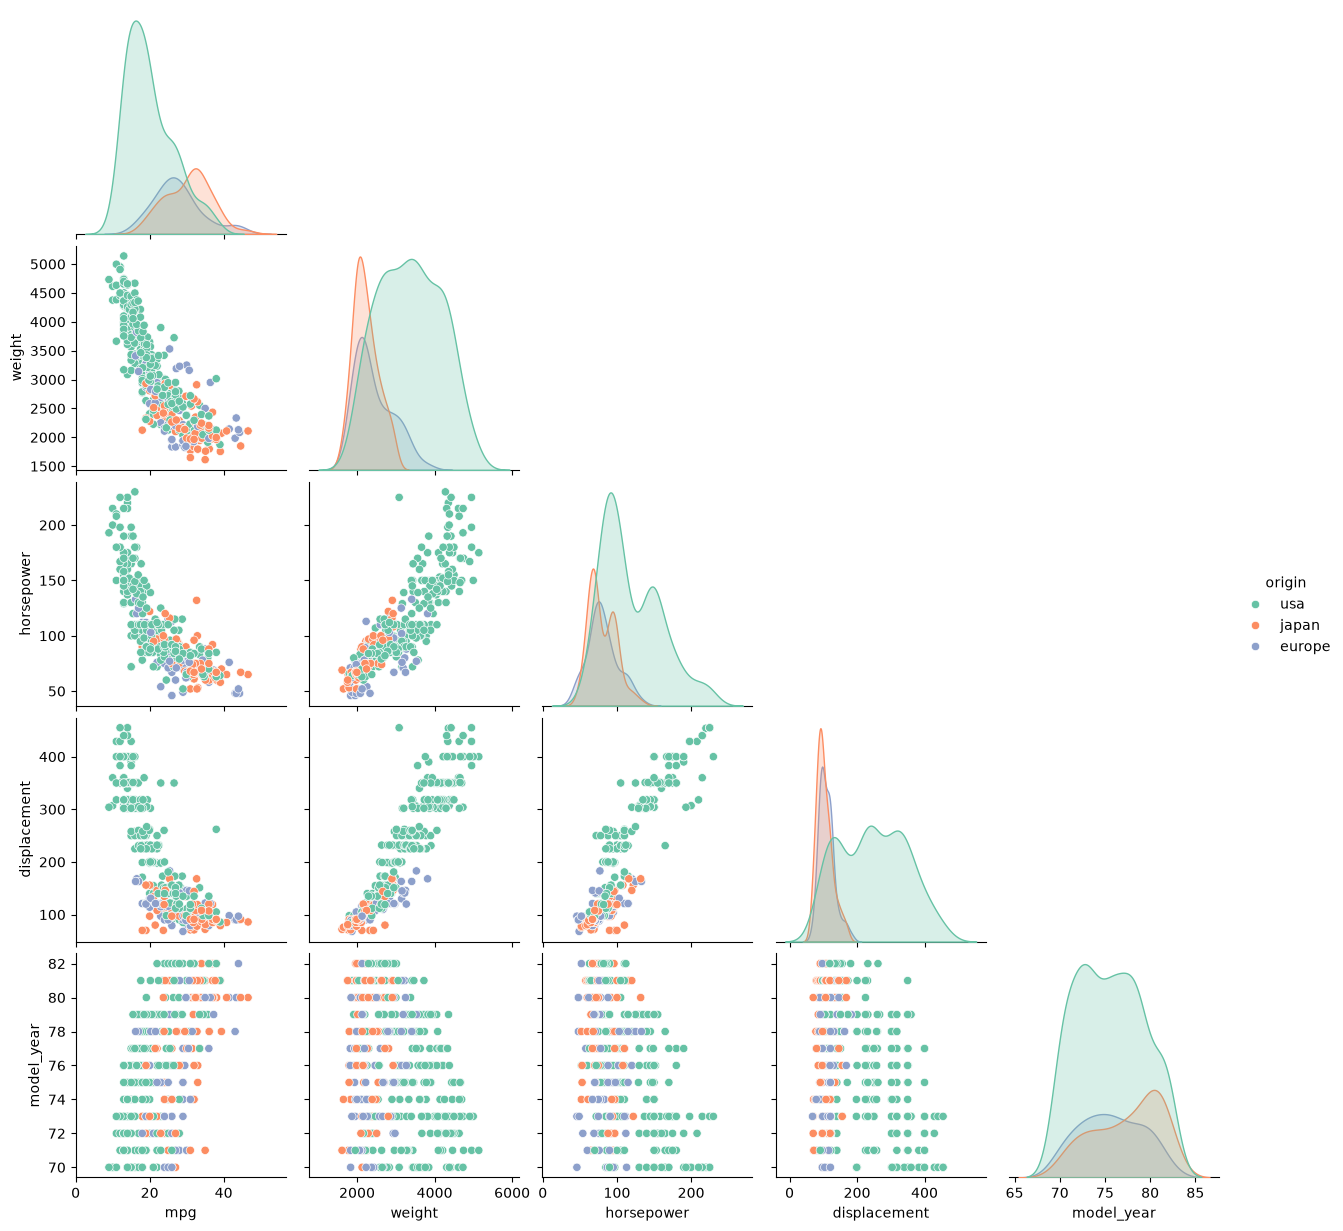

In [66]:
# 15. Realiza un análisis multivariado de `weight` frente a `mpg` incorporando `origin` y
# `cylinders` (mediante color, estilo, facetas u otra codificación). Añade la evolución media de
# `mpg` por `model_year`
cols = ["mpg", "weight", "horsepower", "displacement", "model_year", "origin"]
pair_plot = df[cols].dropna()

# Generación del pairplot del Ejercicio 24
sns.pairplot(
    pair_plot,
    vars=["mpg", "weight", "horsepower", "displacement", "model_year"],
    hue="origin",
    corner=True,
    palette="Set2"
)
plt.show()

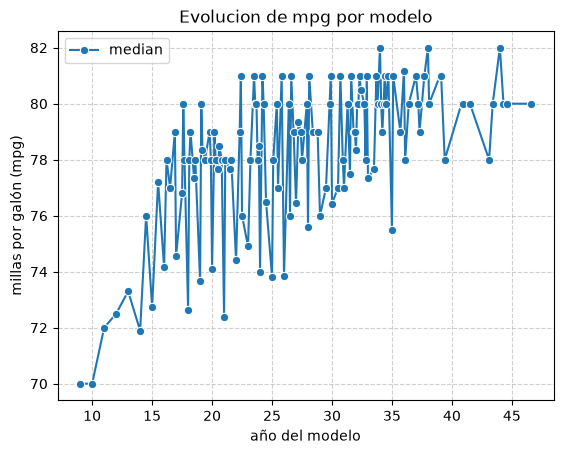

In [69]:
# 16. Analiza la evolución de `mpg` por `model_year`. Calcula media y mediana por año y
# represéntalas en una gráfica de líneas.
mpg_status=df.groupby("mpg")["model_year"].agg(["count","mean","median","std"])


sns.lineplot(data=mpg_status, x="mpg", y="mean", label="median", marker="o")


plt.title("Evolucion de mpg por modelo")
plt.xlabel("año del modelo")
plt.ylabel("millas por galón (mpg)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

               mean  median         std
origin                                 
europe  2423.300000  2240.0  490.043191
japan   2221.227848  2155.0  320.497248
usa     3361.931727  3365.0  794.792506


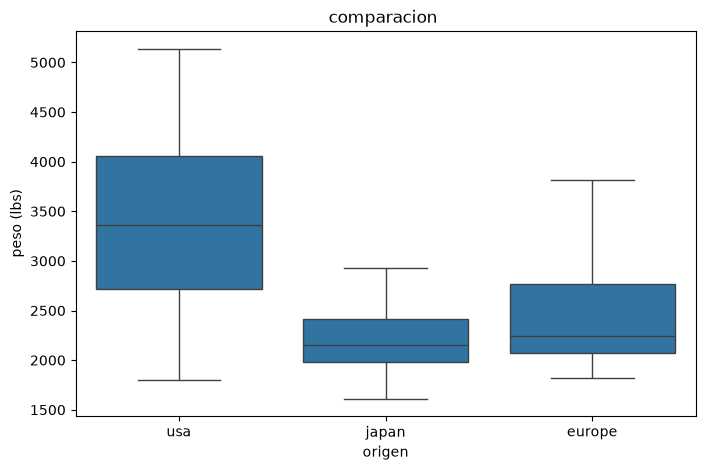

In [71]:
# 17. Compara el `weight` de los automóviles por `origin` mediante estadísticas y boxplots.
# ¿Puede la diferencia de peso ayudar a explicar parte de las diferencias de `mpg` observadas
# entre orígenes?
origin_status = df.groupby("origin")["weight"].agg(["mean", "median", "std"])
print(origin_status)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="origin", y="weight")
plt.title("comparacion ")
plt.xlabel("origen")
plt.ylabel("peso (lbs)")
plt.show()

In [76]:
# 18. Estudia el patrón de los valores faltantes de `horsepower`. Compara su frecuencia por
# `origin`, `cylinders` y `model_year`.
faltantes_horsepower = df[df["horsepower"].isna()]

print('faltantes por pais de origen')
print(faltantes_horsepower["origin"].value_counts())



print(faltantes_horsepower["cylinders"].value_counts())





faltantes por pais de origen
origin
usa       4
europe    2
Name: count, dtype: int64
cylinders
4.0    5
6.0    1
Name: count, dtype: int64


Correlación de Pearson con mpg:
0.42028891210165054
-0.8317409332443344
-0.7784267838977761


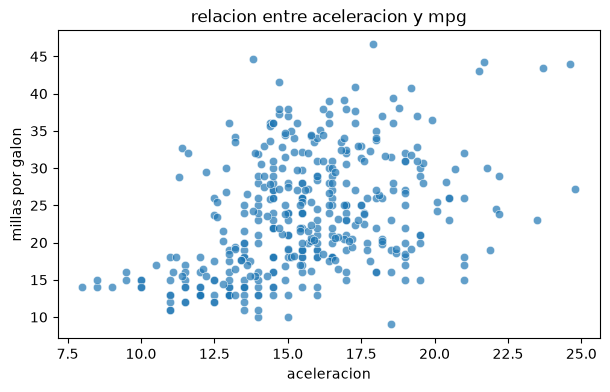

In [79]:

# 19. Analiza la relación entre `acceleration` y `mpg` mediante scatterplot y correlación de
# Pearson. Compara su fuerza con las relaciones de `weight` y `horsepower` con `mpg`.
df = sns.load_dataset("mpg")
correlaciones = df[["mpg", "acceleration", "weight", "horsepower"]].corr()["mpg"]

print("Correlación de Pearson con mpg:")
print(correlaciones.loc['acceleration'])
print(correlaciones.loc['weight'])
print(correlaciones.loc['horsepower'])


plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="acceleration", y="mpg", alpha=0.7)
plt.title("relacion entre aceleracion y mpg")
plt.xlabel("aceleracion")
plt.ylabel("millas por galon")
plt.show()

              displacement  horsepower  weight
displacement         1.000       0.897   0.933
horsepower           0.897       1.000   0.865
weight               0.933       0.865   1.000


Text(0.5, 1.02, 'relaciones entre displacement, horsepower y weight')

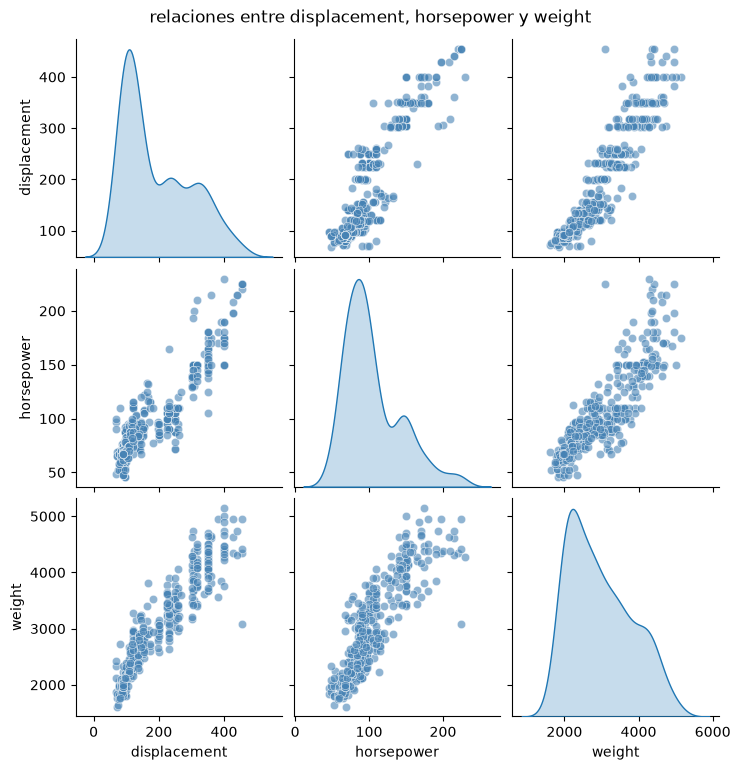

In [89]:
# 0. Explora las relaciones entre `displacement`, `horsepower` y `weight`. Calcula sus
# correlaciones y crea gráficos de dispersión. ¿Qué problema podría aparecer si se usan
# simultáneamente como predictores sin revisar redundancia

var = ["displacement", "horsepower", "weight"]
correlacion = df[var].corr()


print(correlacion.round(3))

sns.pairplot(data=df[var],kind="scatter",diag_kind="kde",plot_kws={"alpha": 0.6, "color": "steelblue"})
plt.suptitle( "relaciones entre displacement, horsepower y weight", y=1.02, fontsize=12)


In [90]:
# 21. Construye una tabla pivote con el `mpg` medio por `cylinders` y `origin`, incluyendo el
# número de automóviles por grupo. ¿El patrón de cilindros se mantiene dentro de cada origen?
# Señala grupos con muestras pequeñas.
tabla = df.pivot_table(
    index="cylinders",
    columns="origin",
    values="mpg",
    aggfunc=["mean", "count"],
).round(2)

print(tabla)


            mean                count             
origin    europe  japan    usa europe japan    usa
cylinders                                         
3            NaN  20.55    NaN    NaN   4.0    NaN
4          28.41  31.60  27.84   63.0  69.0   72.0
5          27.37    NaN    NaN    3.0   NaN    NaN
6          20.10  23.88  19.66    4.0   6.0   74.0
8            NaN    NaN  14.96    NaN   NaN  103.0


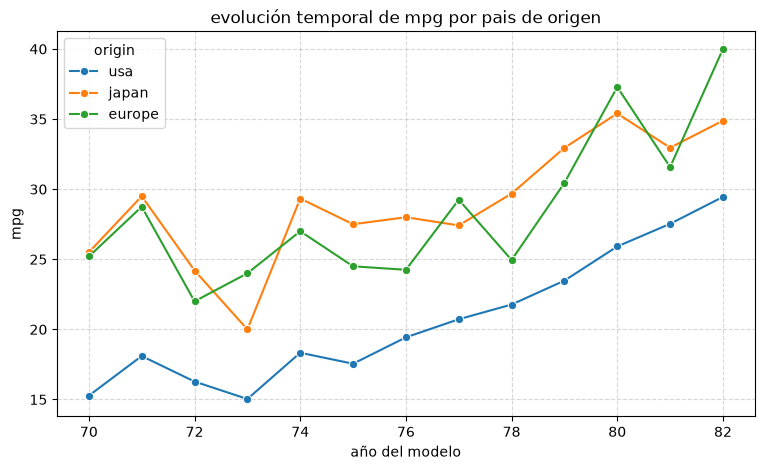

In [91]:
# 22. Compara la evolución temporal de `mpg` entre `origin` usando líneas por grupo. ¿Los tres
# orígenes mejoran con el tiempo? ¿La brecha entre orígenes permanece constante?
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df,
    x="model_year",
    y="mpg",
    hue="origin",
    marker="o",
    errorbar=None,
)

plt.title("evolución temporal de mpg por pais de origen")
plt.xlabel("año del modelo")
plt.ylabel("mpg")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [92]:
# 23. Compara los outliers de `horsepower` detectados mediante 1.5·IQR y mediante |z| > 3.
# Lista los vehículos más extremos y explica por qué un método puede ser más estricto que el
# otro en una distribución asimétrica
datos = df.dropna(subset=["horsepower"]).copy()
hp = datos["horsepower"]

Q1 = hp.quantile(0.25)
Q3 = hp.quantile(0.75)
IQR = Q3 - Q1
limite_superior_iqr = Q3 + 1.5 * IQR
outliers_iqr = datos[hp > limite_superior_iqr]

mean_hp = hp.mean()
std_hp = hp.std()
z_scores = (hp - mean_hp) / std_hp
outliers_z = datos[abs(z_scores) > 3]

print(f"limite superior IQR: {limite_superior_iqr:.2f} HP")
print(f"outliers por IQR: {len(outliers_iqr)} vehículos")
print(f"outliers por z-score (|z| > 3): {len(outliers_z)} vehículos")

print("\nVehículos más extremos (Potencia > 220 HP):")
print(
    datos[hp >= 220][["name", "horsepower", "weight", "model_year", "origin"]]
)

limite superior IQR: 202.50 HP
outliers por IQR: 10 vehículos
outliers por z-score (|z| > 3): 5 vehículos

Vehículos más extremos (Potencia > 220 HP):
                         name  horsepower  weight  model_year origin
6            chevrolet impala       220.0    4354          70    usa
8            pontiac catalina       225.0    4425          70    usa
13    buick estate wagon (sw)       225.0    3086          70    usa
95   buick electra 225 custom       225.0    4951          73    usa
116        pontiac grand prix       230.0    4278          73    usa


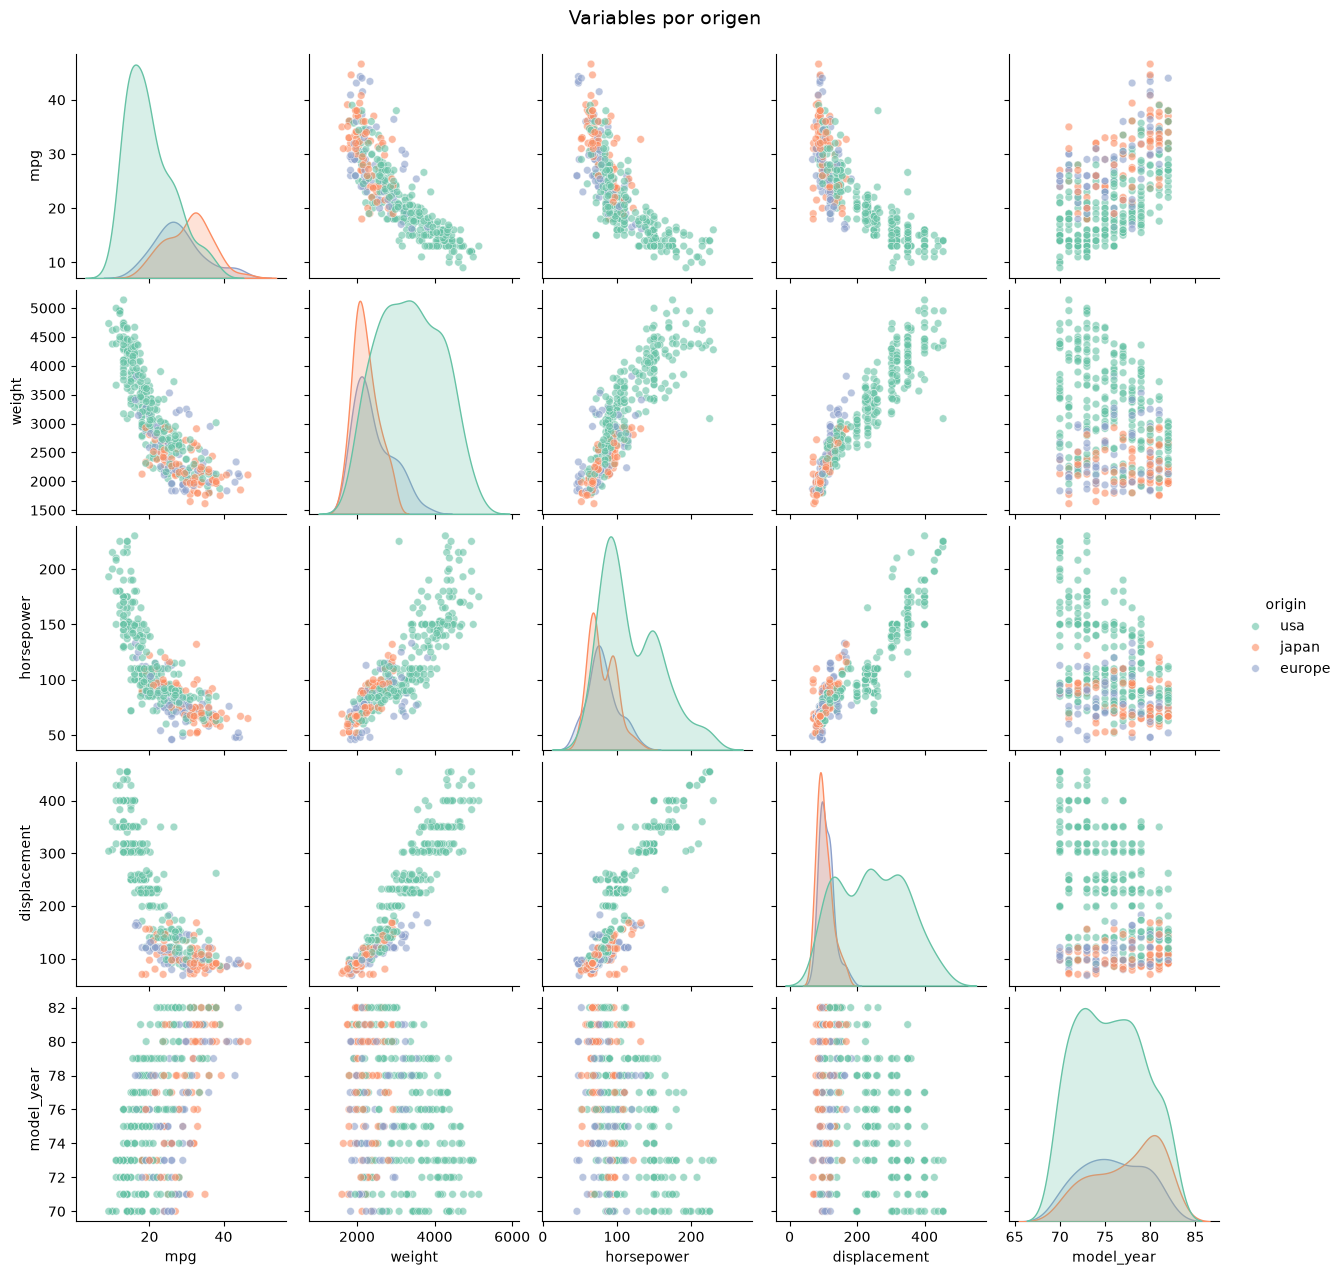

In [94]:
# 24. Construye un `pairplot` con `mpg`, `weight`, `horsepower`, `displacement` y
# `model_year`, usando `origin` como color.
var = ["mpg", "weight", "horsepower", "displacement", "model_year"]

sns.pairplot(
    data=df,
    vars=var,
    hue="origin",
    palette="Set2",
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 30},
)

plt.suptitle(
    "Variables por origen", y=1.02, fontsize=14
)
plt.show()

In [ ]:
# 25. Elabora un “registro de decisiones” para preparar un análisis posterior: decide qué harías
# con los nulos de `horsepower`, `name`, `origin`, los outliers de potencia y las variables
# altamente correlacionadas.

# se propondrá imputar los valores nulos de horsepower con la mediana y completar los de origin con la moda. 
# Para name, se propondrá mantener los nulos como "Unknown" o considerar eliminar la variable por su carácter 
# identificativo. Los outliers de horsepower se propondrá evaluar antes de eliminarlos. Finalmente 
# se propondrá analizar las variables altamente correlacionadas y seleccionar solo una cuando presenten 
# información redundante.